# ⚡ Baryonic Velocity: Sign-Preserving Quadrature
### EPS Research High-School Exploration Track — Ages 15-18

The total baryonic velocity combines gas, disk, and bulge contributions:

$$V_{\rm bar} = \text{sign}(V_{\rm gas})\sqrt{|V_{\rm gas}|^2 + \Upsilon V_{\rm disk}^2 + \Upsilon_b V_{\rm bul}^2}$$

Why sign-preserving? At inner radii, thermal gas pressure can exceed
rotation, making Vgas effectively negative. We preserve this sign
to avoid artificially boosting the baryonic contribution.

**Prerequisites:** Vectors, square roots, quadrature addition

NGC2403: Vgas negative rows = 0

Difference between signed and unsigned at inner points:
  R=0.2 kpc: plain=23.2, signed=23.2, diff=0.0
  R=0.3 kpc: plain=35.3, signed=35.3, diff=0.0
  R=0.4 kpc: plain=47.0, signed=47.0, diff=0.0
  R=0.5 kpc: plain=56.7, signed=56.7, diff=0.0
  R=0.6 kpc: plain=63.8, signed=63.8, diff=0.0


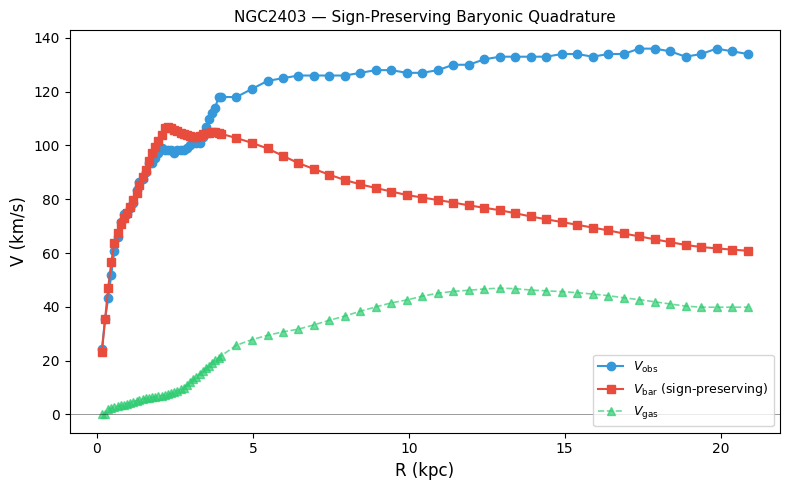

In [1]:
import json, numpy as np, matplotlib.pyplot as plt
with open('rotation_curve_corpus_v7.json') as f:
    corpus=json.load(f)
g=next(g for g in corpus['galaxies'] if g['galaxy']=='NGC2403')
d=g['data']
R=np.array([p['Rad'] for p in d]); Vobs=np.array([p['Vobs'] for p in d])
Vgas=np.array([p['Vgas'] for p in d]); Vdisk=np.array([p['Vdisk'] for p in d])
Vbul=np.array([p['Vbul'] for p in d])
Upsilon=1.0
Vbar_plain=np.sqrt(Vgas**2+Upsilon*Vdisk**2+Vbul**2)
Vbar_signed=np.where(Vgas<0,-np.sqrt(Vgas**2+Upsilon*Vdisk**2+Vbul**2),
                            np.sqrt(Vgas**2+Upsilon*Vdisk**2+Vbul**2))
print(f"NGC2403: Vgas negative rows = {(Vgas<0).sum()}")
print("\nDifference between signed and unsigned at inner points:")
for r,vp,vs in zip(R[:5],Vbar_plain[:5],Vbar_signed[:5]):
    print(f"  R={r:.1f} kpc: plain={vp:.1f}, signed={vs:.1f}, diff={vp-vs:.1f}")
fig,ax=plt.subplots(figsize=(8,5))
ax.plot(R,Vobs,'o-',color='#3498db',lw=1.5,label=r'$V_{\rm obs}$')
ax.plot(R,Vbar_signed,'s-',color='#e74c3c',lw=1.5,label=r'$V_{\rm bar}$ (sign-preserving)')
ax.plot(R,Vgas,'^--',color='#2ecc71',lw=1.2,alpha=0.7,label=r'$V_{\rm gas}$')
ax.axhline(0,color='black',lw=0.7,alpha=0.4)
ax.set_xlabel('R (kpc)',fontsize=12); ax.set_ylabel('V (km/s)',fontsize=12)
ax.set_title('NGC2403 — Sign-Preserving Baryonic Quadrature',fontsize=11)
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig('hs_b_04_quadrature.png',dpi=150,bbox_inches='tight'); plt.show()